<a href="https://colab.research.google.com/github/TurkuNLP/intro-to-nlp/blob/master/ex_task1_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise task 1 (Basic): Subword tokenization

**PART A:**

English text:
```OpenAI's large language models process text using tokens, which are common sequences of characters found in a set of text. The models learn to understand the statistical relationships between these tokens, and excel at producing the next token in a sequence of tokens. Learn more.```

Finnish text (DeepL translation):
```OpenAI:n suuret kielimallit käsittelevät tekstiä käyttämällä tokeneita, jotka ovat tekstissä esiintyviä tavallisia merkkijonoja. Mallit oppivat ymmärtämään näiden tokenien välisiä tilastollisia suhteita ja ovat erityisen taitavia tuottamaan seuraavan tokenin tokenijonossa. Lue lisää.```

Finnish tokens: 79 (284 characters)

English tokens: 52 (280 characters)

Fin/Eng ratio: 79/52 = 1.519


--> The number of characters is almost the same, but Finnish has many more tokens. This becomes apparent in the visualization, most English words are not split into subwords, whereas most Finnish words are.

--> Although we cannot draw broad conclusions from a single example, the ratios in your examples during the class constantly showed that Finnish had more tokens than English. The fin/eng ratio was typically close to 1.5, but there was some variation.

Consequences:
- **Price**: Commercial models are priced based on the number of input tokens and output tokens. Assuming identical content, Finnish is more expensive because the same content results in more tokens on both the input and output sides.
- **Computational cost**: Even when running a model locally, the required computation increases with the number of tokens. This means more computational resources are needed, and processing takes longer. So even if you are do not paying in euros or dollars, you are still paying in machine time and memory usage.
- **Maximum context length**: LLMs have a maximum context length, which defines how many tokens they can process at once. This means models can handle longer English texts than Finnish texts of the same content, because English tend to produce fewer subwords. Many recent models have context lengths of up to a million tokens, but this can still matter when processing very long texts.
- **Performance (quality)**: More subwords may also affect quality, because heavier fragmentation can make it harder for the model to represent and process meaning consistently. However, this is something we cannot say for sure and would need to be tested experimentally.




**PART B**

Here, the main objective was to illustrate that the most frequent words are usually not split into subwords, whereas words further down the frequency list tend to be fragmented more heavily.

Also, among the most frequent words that are split into multiple subwords, many contain an apostrophe, which is a special case. Many tokenizers split apostrophes by default, so even if `don't` were frequent enough to appear as a single subword, it often still would not.



In [8]:
!pip install -q wordfreq

from wordfreq import top_n_list
from transformers import AutoTokenizer

words = top_n_list('en', 100000)
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

In [10]:
subwords = []
for i,word in enumerate(words):
  tokenized = tokenizer.tokenize(word)
  if len(tokenized) > 1:
    subwords.append((i+1, word, tokenized))
  if len(subwords) >= 20: # done!
    break

for rank, word, tokenized in subwords:
  print(rank, word, tokenized)

55 it's ['it', "'", 's']
68 don't ['don', "'", 't']
74 i'm ['i', "'", 'm']
140 you're ['you', "'", 're']
143 that's ['that', "'", 's']
154 can't ['can', "'", 't']
183 i've ['i', "'", 've']
195 didn't ['didn', "'", 't']
227 he's ['he', "'", 's']
267 there's ['there', "'", 's']
271 doesn't ['doesn', "'", 't']
321 they're ['they', "'", 're']
356 i'll ['i', "'", 'll']
376 isn't ['isn', "'", 't']
394 we're ['we', "'", 're']
433 i'd ['i', "'", 'd']
462 won't ['won', "'", 't']
495 u.s ['u', '.', 's']
536 wasn't ['wasn', "'", 't']
552 she's ['she', "'", 's']


[(500, 'child'), (1000, 'response'), (1500, 'royal'), (2000, 'hundred'), (2500, 'scared')]


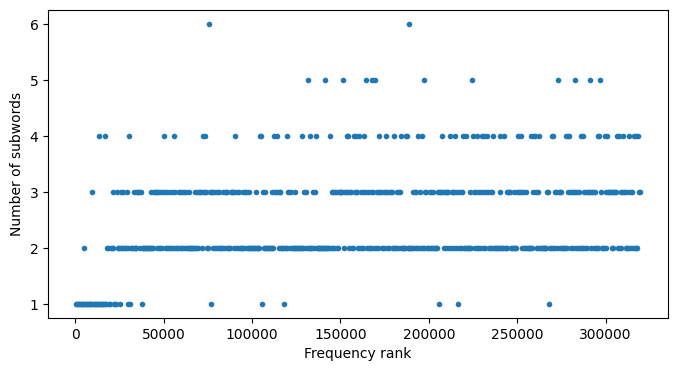

In [18]:
# This part is extra:

# Let's take top 500,000 words, sample every 500th word, and plot number of subwords against rank
import matplotlib.pyplot as plt

words = top_n_list('en', 500000) # take more

sample = [(i+1, w) for i, w in enumerate(words) if (i+1)%500==0] # keep only those ranks that are divisible by 500
print(sample[:5])

subword_counts = [len(tokenizer.tokenize(w)) for i, w in sample]
ranks = [i for i, w in sample]

# plot
plt.figure(figsize=(8, 4))
plt.plot(ranks, subword_counts, ".")
plt.xlabel("Frequency rank")
plt.ylabel("Number of subwords")
plt.show()


From this plot we see clearly that words further down the frequency list tend to be fragmented more heavily (at least two subwords).